In [1]:
import sys
sys.path.insert(0, '../')
import pandas as pd
import numpy as np
import yaml
import unicodedata
from helpers_finalizacion_carrera import get_egresados_biologia, plot_egresados_biologia_por_anio

In [2]:
personas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_personas_desde_2005.csv')
personas['dni'] = personas['dni'].astype(str)
actas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_actas_desde_2005.csv', encoding='latin-1', dtype={'dni': str})

In [3]:
#cambio los registros de la columna 'materia' para que esten en mayuscula, sin espacios al principio ni al final, y sin tildes.
actas['materia'] = actas['materia'].str.upper().str.strip()
actas['materia'] = actas['materia'].apply(lambda x: unicodedata.normalize('NFKD', x).encode('ASCII', 'ignore').decode('ASCII'))

## Biología

In [4]:
materias_biologia = (
    actas[actas['carrera'] == 'Licenciatura en Ciencias Biológicas']['materia']
    .value_counts()
    .rename_axis('materia')
    .reset_index(name='cantidad')
)

materias_biologia

,materia,cantidad
0,INTRODUCCION A LA BIOLOGIA MOLECULAR Y CELULAR,8643
1,INTRODUCCION A LA BOTANICA,7801
2,ANALISIS MATEMATICO I,7505
3,QUIMICA GENERAL E INORGANICA I,7181
4,ELEMENTOS DE CALCULO NUMERICO,6460
...,...,...
159,ELEMENTOS DE TEORIA DE NUMEROS,1
160,BIOESTRATIGRAFIA,1
161,PALEONTOLOGIA DE INVERTEBRADOS,1
162,FOTOQUIMICA Y ESPECTROSCOPIA,1


In [5]:
materias_biologia.to_csv('materias_biologia.csv', index=False)

Notamos que los distintos planes ofrecen materias distintas, incluso el plan de 1984 cuenta con un listado más extenso de materias.

In [6]:
with open('../../constants/materias_biologia.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)
    materias_plan1984 = [m for m in config['planes'][0]['materias']]

In [7]:
len(materias_plan1984)

140

In [8]:
with open('../../constants/materias_biologia.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)
    materias_plan2019 = [m for m in config['planes'][1]['materias']]

In [9]:
len(materias_plan2019)

105

Juntamos las listas

In [10]:
with open('../../constants/materias_biologia.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)
    materias = [m for plan in config['planes'] for m in plan['materias']]

In [11]:
materias = [unicodedata.normalize('NFKD', m).encode('ASCII', 'ignore').decode('ASCII').upper() for m in materias]
materias = list(set(materias))
materias

['GENETICA MOLECULAR BACTERIANA I Y GENETICA MOLECULAR BACTERIANA II',
 'INTRODUCCION A LA COMPUTACION',
 'DASONOMIA (FAUBA)',
 'OCEANOGRAFIA BIOLOGICA',
 'FISIOLOGIA ANIMAL COMPARADA',
 'PROTOZOOLOGIA',
 'BIOMETRIA II',
 'VERTEBRADOS',
 'OCEANOGRAFIA GENERAL',
 'BIOLOGIA SENSORIAL ANIMAL',
 'ECOFISIOLOGIA VEGETAL',
 'FISICA I',
 'FISICA II',
 'ENDOCRINOLOGIA DE VERTEBRADOS',
 'SEDIMENTOLOGIA',
 'INTRODUCCION A LA BIOINFORMATICA MOLECULAR',
 'ENTOMOLOGIA',
 'ECOLOGIA DE POBLACIONES',
 'PROTECCION Y CONSERVACION DE LA NATURALEZA (UNLP)',
 'INTRODUCCION A LA BIOLOGIA MOLECULAR Y CELULAR',
 'FISIOLOGIA DEL SISTEMA NERVIOSO',
 'ANALISIS MATEMATICO I',
 'EVOLUCION',
 'MICROBIOLOGIA',
 'INMUNOQUIMICA',
 'FISIOLOGIA DE INSECTOS',
 'GENETICA DE POBLACIONES',
 'ICTIOLOGIA (UNLP)',
 'ANALISIS BIOLOGICOS II',
 'BIOLOGIA DE LA CONSERVACION',
 'INVERTEBRADOS I',
 'PALEOBOTANICA',
 'BIOFISICA',
 'ECOLOGIA GENERAL',
 'PALINOESTRATIGRAFIA',
 'LIMNOLOGIA',
 'GENETICA MOLECULAR DEL DESARROLLO',
 'EMBRIO

In [12]:
len(materias)

166

Sin embargo, al invetigar los planes de ambas carreras, nos interamos de que lo que debería cambiar entre ambos planes es que en 2019 se agregó una materia obligatoria, "Evolución" y cambio lo necesario para aprobar el ciclo superior. 

Intentemos verificar, por lo menos con unos ejemplos, que esto se ve reflejado en los datos

In [13]:
materias_biologia[materias_biologia['materia'].isin(materias)].shape

(130, 2)

In [14]:
materias_en_actas = materias_biologia['materia'].tolist()

In [15]:
[m for m in materias if m not in materias_en_actas]

['GENETICA MOLECULAR BACTERIANA I Y GENETICA MOLECULAR BACTERIANA II',
 'DASONOMIA (FAUBA)',
 'PROTOZOOLOGIA',
 'OCEANOGRAFIA GENERAL',
 'ECOFISIOLOGIA VEGETAL',
 'SEDIMENTOLOGIA',
 'PROTECCION Y CONSERVACION DE LA NATURALEZA (UNLP)',
 'ICTIOLOGIA (UNLP)',
 'PALINOESTRATIGRAFIA',
 'GENETICA MOLECULAR DEL DESARROLLO',
 'GEOBOTANICA',
 'ANTROPOLOGIA BIOLOGICA Y PALEO ANTROPOLOGIA (FYL UBA)',
 'BIOINFORMATICA Y BIOLOGIA COMPUTACIONAL',
 'TECNICAS EN BIOQUIMICA Y BIOLOGIA MOLECULAR',
 'FARMACOLOGIA (FFYB UBA)',
 'GENETICA',
 'PALEONTOLOGIA DE VERTEBRADOS (UNLP)',
 'FOTOINTERPRETACION',
 'PLANCTOLOGIA',
 'PLANIFICACION Y CONSERVACION DEL USO DE LA TIERRA (FAUBA)',
 'ANALISIS DE BIOFACIES',
 'CONCEPTOS Y TECNICAS DE BIOTECNOLOGIA',
 'BIOLOGIA DEL DESARROLLO REPRODUCTIVO DE PLANTAS',
 'ECOLOGIA DEL COMPORTAMIENTO ANIMAL',
 'CLIMATOLOGIA',
 'PALINOLOGIA',
 'ECOLOGIA E EPIDEMIOLOGIA DE INFECCIONES PARASITARIAS',
 'HERPETOLOGIA (UNLP)',
 'HELMINTOLOGIA',
 'ANATOMIA ANIMAL COMPARADA (UNLP)',
 'CO

Cuando revisamos que esten las materias obligatorias, encuentro que solo falta GENETICA del plan de 2019, sospecho que se sigue llamando GENETICA I o se le colocó un nombre similar, podemos revisar ejemplos.

In [16]:
materias_troncales_bio = [
    "Biometría",
    "Ecología General",
    "Fisica II",
    "Genética I",
    "Introducción a la Biología Molecular y Celular",
    "Introducción a la Botánica",
    "Introducción a la Zoología",
    "Análisis Matemático I",
    "Elementos de Cálculo Numérico",
    "Física I",
    "Química Biológica",
    "Química General e Inorgánica I",
    "Química Orgánica",
]
materias_troncales_bio = [unicodedata.normalize('NFKD', m).encode('ASCII', 'ignore').decode('ASCII').upper() for m in materias_troncales_bio]

In [17]:
[m for m in materias_troncales_bio if m not in materias_en_actas]

[]

In [18]:
materias_troncales_plan2019 = [
    "Biometria",
    "Ecología General",
    "Electromagnetismo y Óptica",
    "Evolución",
    "Genética",
    "Introducción a la Biología Molecular y Celular",
    "Introducción a la Botánica",
    "Introducción a la Zoología",
    "Matemática I",
    "Matemática II",
    "Mecánica y Termodinámica",
    "Química Biológica",
    "Química General e Inorgánica I",
    "Química Orgánica",
]
materias_troncales_plan2019 = [unicodedata.normalize('NFKD', m).encode('ASCII', 'ignore').decode('ASCII').upper() for m in materias_troncales_plan2019]

In [19]:
[m for m in materias_troncales_plan2019 if m not in materias_en_actas]

['GENETICA']

Algunas de las que no se encuentran son del plan nuevo:

* OCEANOGRAFIA GENERAL
* GENETICA <-- hay que revisar porque es del ciclo troncal, no debería faltar

In [20]:
materias_biologia[materias_biologia['materia'].isin(materias_troncales_bio)].sort_values(by='cantidad', ascending=False)

,materia,cantidad
0,INTRODUCCION A LA BIOLOGIA MOLECULAR Y CELULAR,8643
1,INTRODUCCION A LA BOTANICA,7801
2,ANALISIS MATEMATICO I,7505
3,QUIMICA GENERAL E INORGANICA I,7181
4,ELEMENTOS DE CALCULO NUMERICO,6460
5,INTRODUCCION A LA ZOOLOGIA,6383
6,BIOMETRIA,6167
7,GENETICA I,5427
8,QUIMICA ORGANICA,5321
9,ECOLOGIA GENERAL,5308


In [21]:
materias_biologia[materias_biologia['materia'].isin(materias_troncales_plan2019)].sort_values(by='cantidad', ascending=False)

,materia,cantidad
0,INTRODUCCION A LA BIOLOGIA MOLECULAR Y CELULAR,8643
1,INTRODUCCION A LA BOTANICA,7801
3,QUIMICA GENERAL E INORGANICA I,7181
5,INTRODUCCION A LA ZOOLOGIA,6383
6,BIOMETRIA,6167
8,QUIMICA ORGANICA,5321
9,ECOLOGIA GENERAL,5308
10,QUIMICA BIOLOGICA,5263
11,EVOLUCION,4490
12,MATEMATICA I,4316


In [22]:
biologos = personas[personas['carrera_principal'] == 'Licenciatura en Ciencias Biológicas'][['dni', 'año_inscripcion_facultad']]

In [23]:
actas_biologos = actas[actas['dni'].isin(biologos['dni'])]

In [24]:
actas_biologos = actas_biologos.merge(biologos, on='dni', how='left').sort_values(by=['año_inscripcion_facultad'])

In [25]:
actas_biologos[(actas_biologos['año_inscripcion_facultad'] >= 2019) & (actas_biologos['materia'].isin(materias_troncales_plan2019))]['materia'].value_counts()

materia
MATEMATICA I                                      4341
INTRODUCCION A LA BIOLOGIA MOLECULAR Y CELULAR    3434
INTRODUCCION A LA BOTANICA                        3252
QUIMICA ORGANICA                                  2210
MATEMATICA II                                     2158
INTRODUCCION A LA ZOOLOGIA                        2143
BIOMETRIA                                         2013
QUIMICA GENERAL E INORGANICA I                    1546
QUIMICA BIOLOGICA                                 1463
ECOLOGIA GENERAL                                  1410
ELECTROMAGNETISMO Y OPTICA                        1259
MECANICA Y TERMODINAMICA                           822
EVOLUCION                                          597
Name: count, dtype: int64

In [26]:
actas_biologos[(actas_biologos['año_inscripcion_facultad'] >= 2019) & (actas_biologos['materia'].isin(materias_troncales_bio))]['materia'].value_counts()

materia
INTRODUCCION A LA BIOLOGIA MOLECULAR Y CELULAR    3434
INTRODUCCION A LA BOTANICA                        3252
QUIMICA ORGANICA                                  2210
INTRODUCCION A LA ZOOLOGIA                        2143
BIOMETRIA                                         2013
QUIMICA GENERAL E INORGANICA I                    1546
QUIMICA BIOLOGICA                                 1463
ECOLOGIA GENERAL                                  1410
GENETICA I                                        1217
ANALISIS MATEMATICO I                              128
ELEMENTOS DE CALCULO NUMERICO                       64
Name: count, dtype: int64

In [33]:
egresados_bio = get_egresados_biologia(
    ['Licenciatura en Ciencias Biológicas'],
    '../../constants/materias_biologia.yaml',
    '../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_personas_desde_2005.csv',
    '../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_actas_desde_2005.csv',
    min_obligatorias_1984 = 13,
    min_ciclo_superior_1984 = 8,
    min_obligatorias_2019 = 14,
    min_ciclo_superior_2019 = 6,
)

In [28]:
actas_biologos[actas_biologos['materia'] == 'TESIS DE LICENCIATURA'].assign(
    anio=lambda x: pd.to_datetime(x['fecha']).dt.year
).groupby('anio').size().reset_index(name='cantidad')

,anio,cantidad
0,2019,1
1,2020,2
2,2021,1
3,2022,16
4,2023,38
5,2024,93
6,2025,126


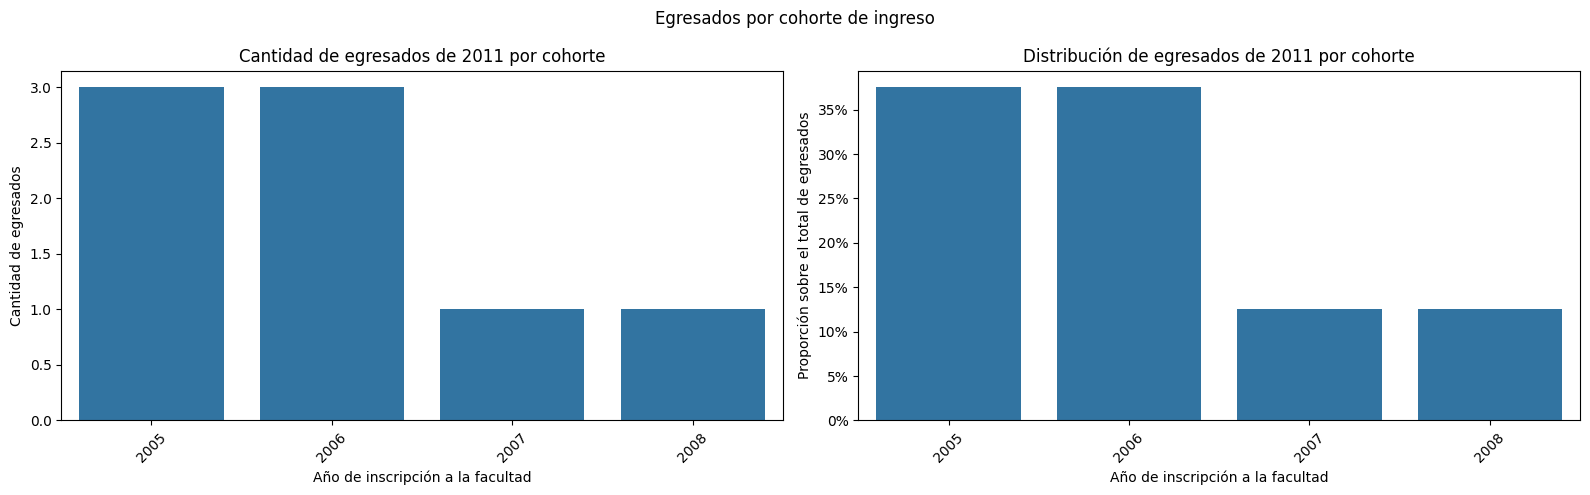

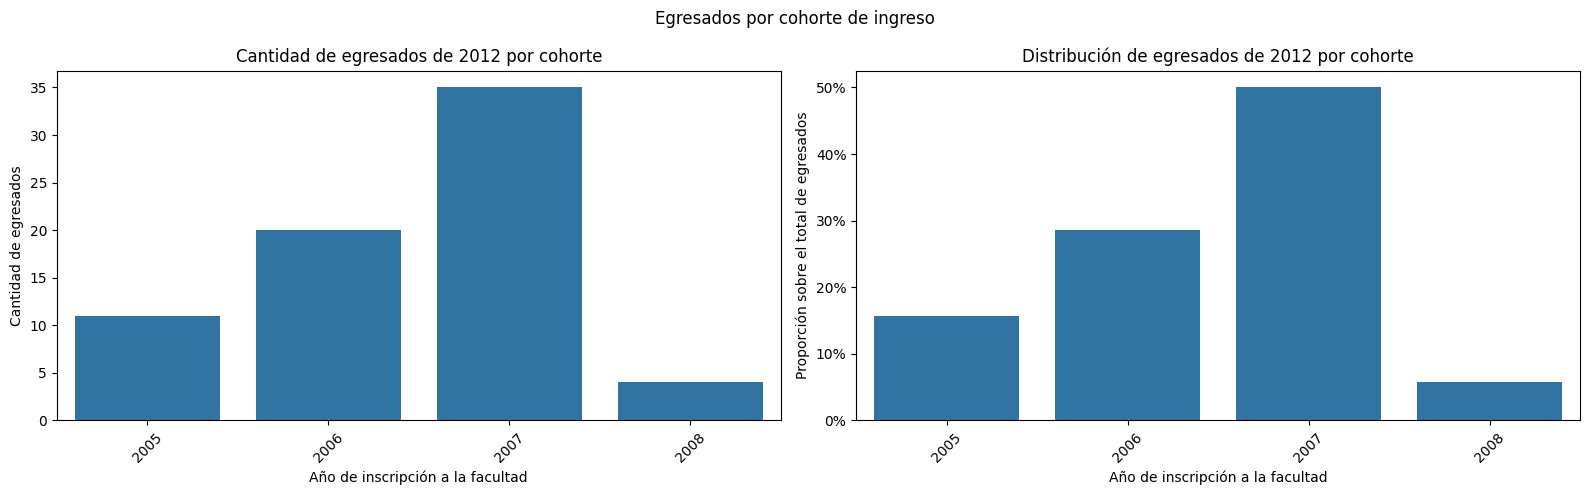

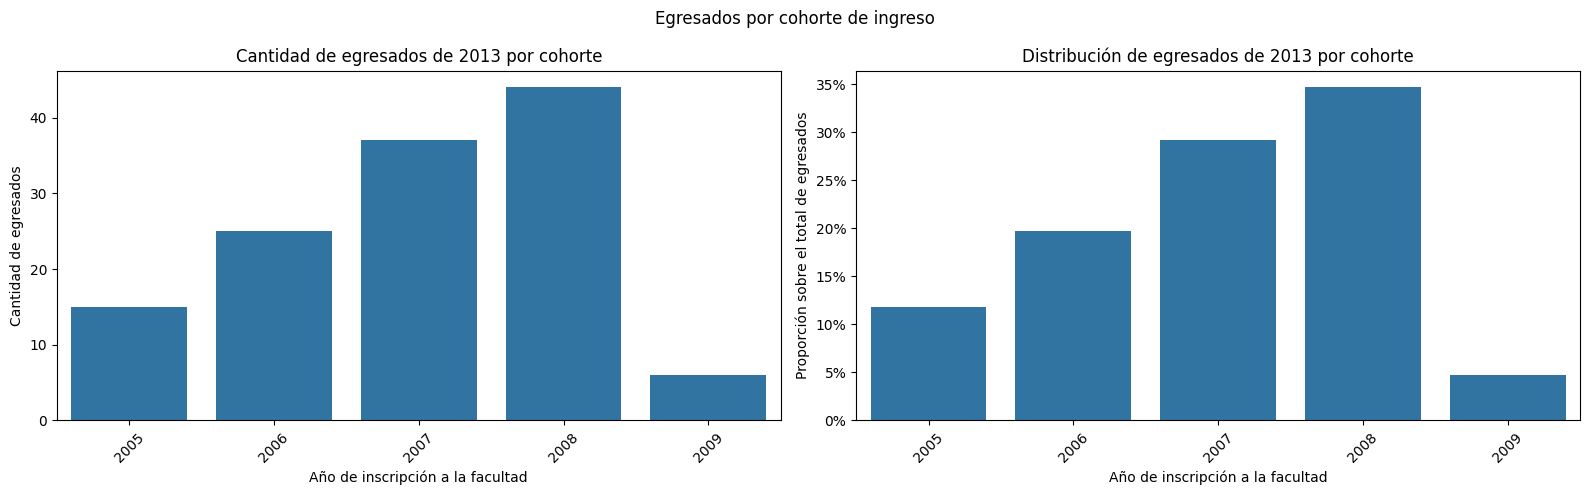

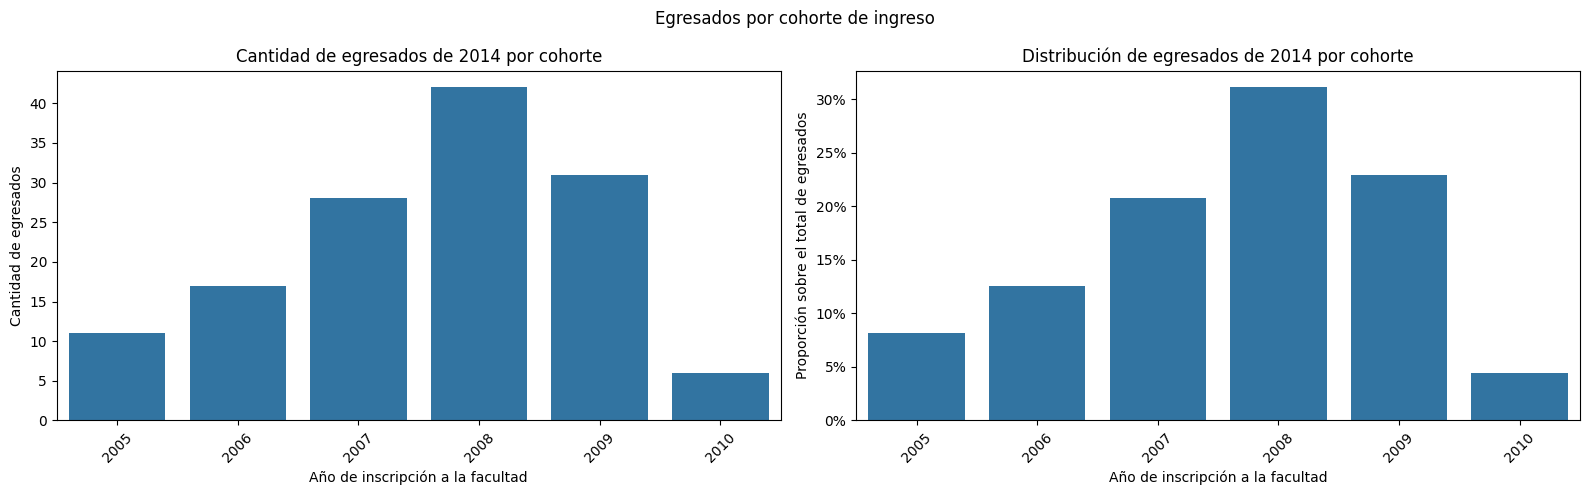

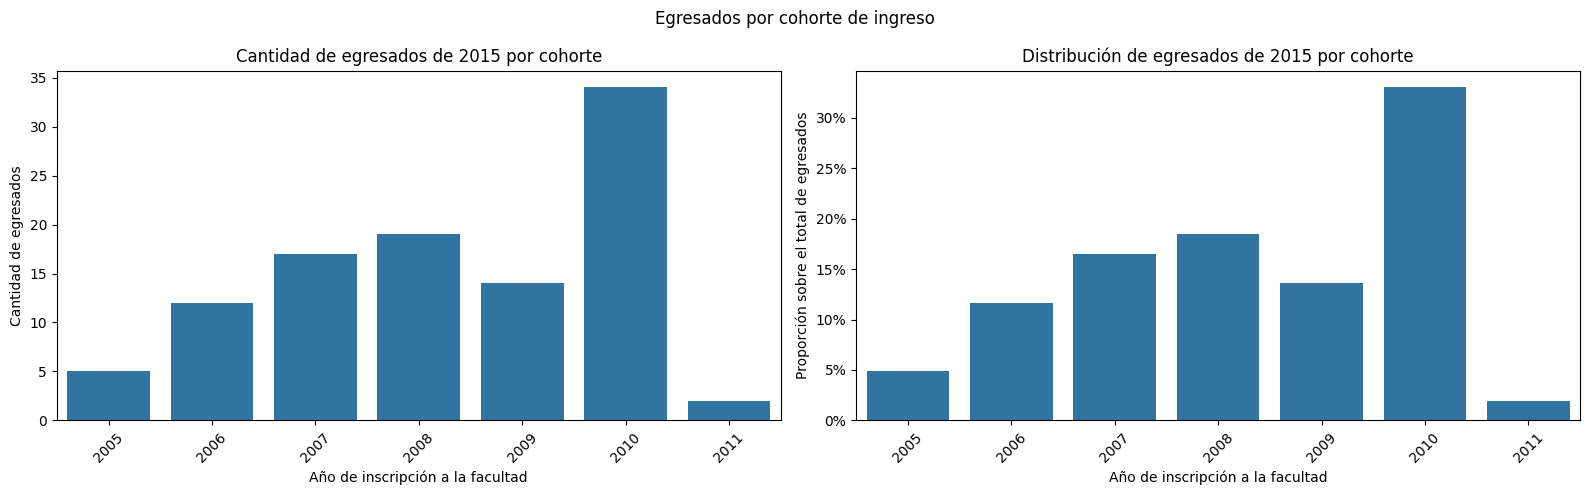

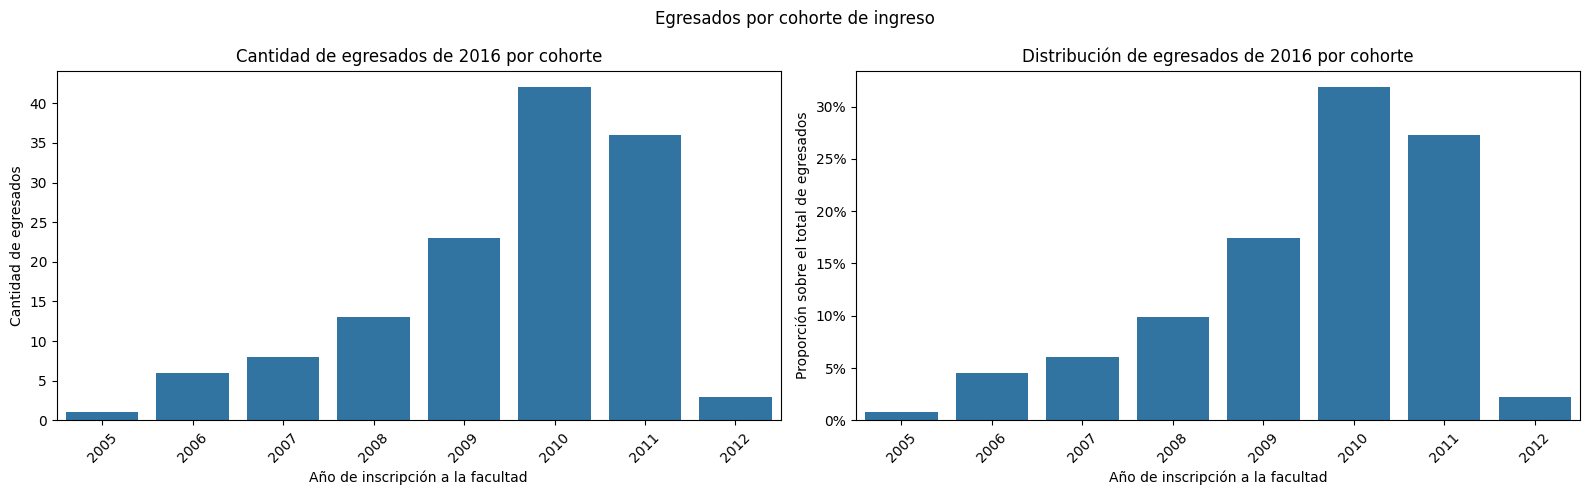

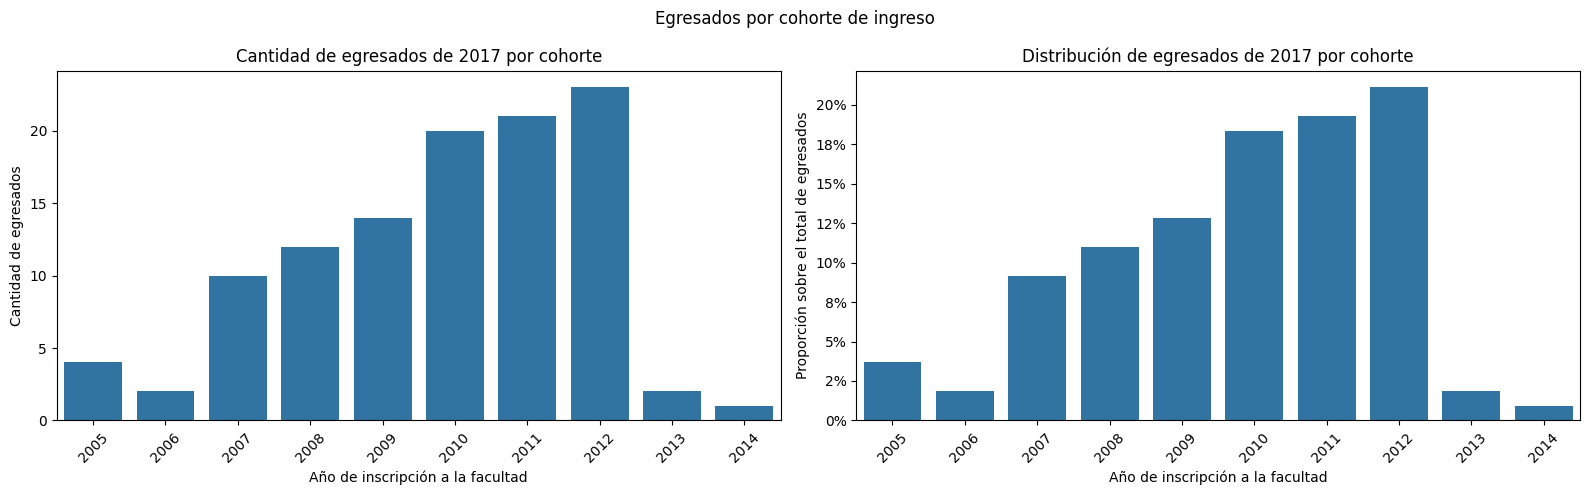

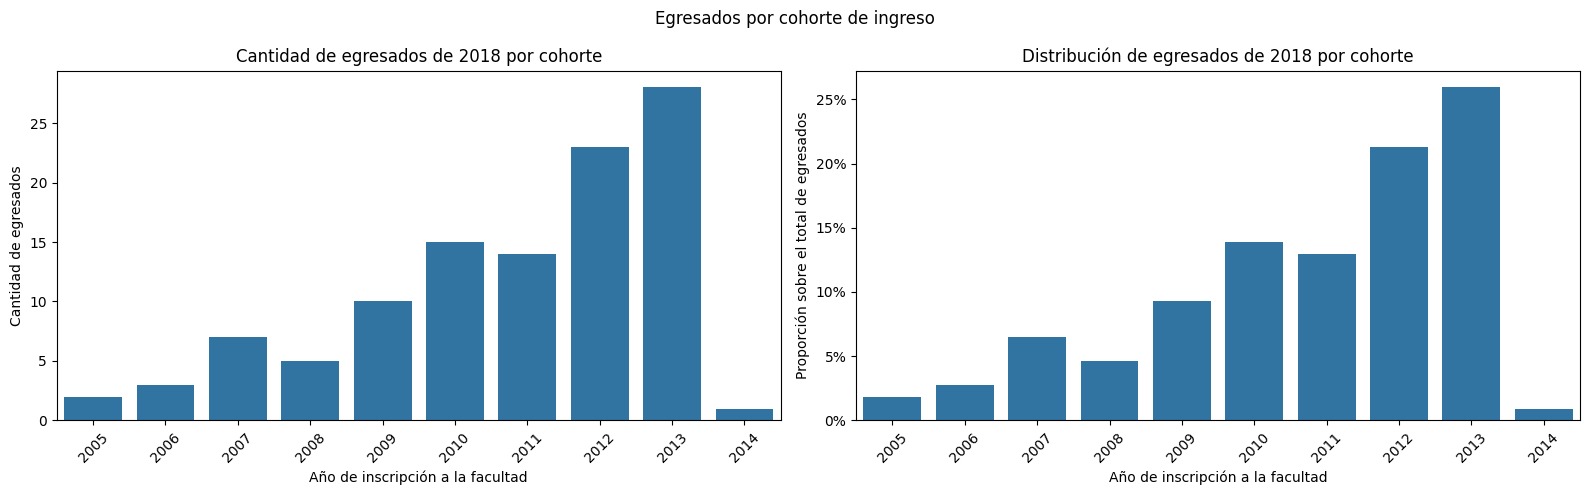

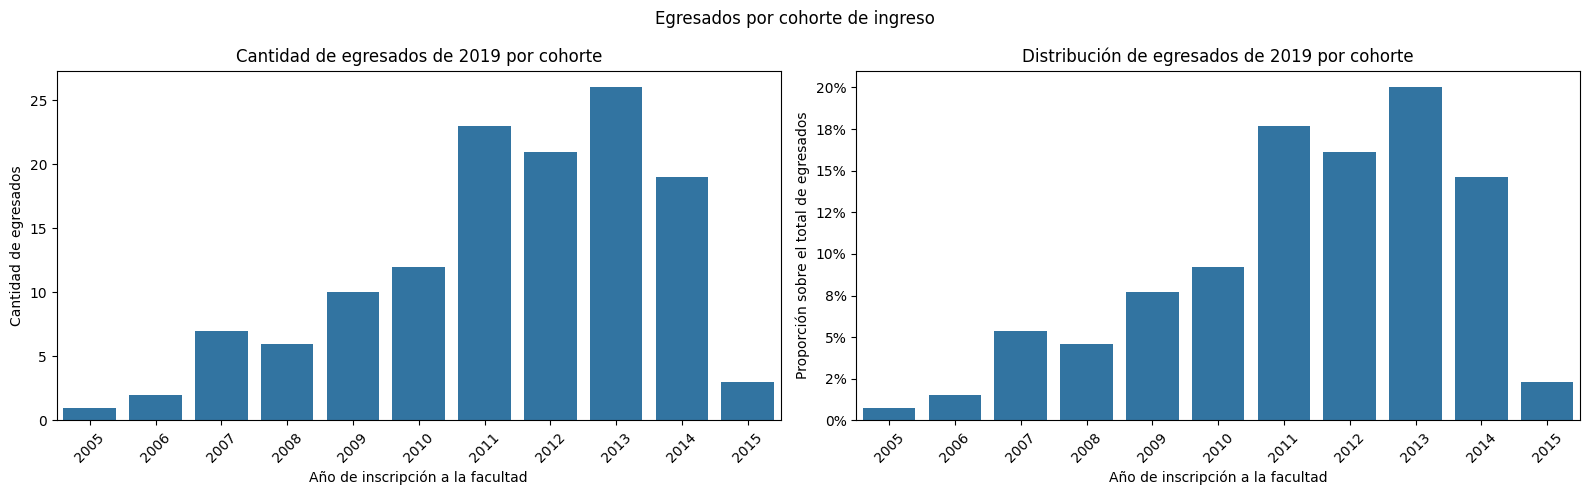

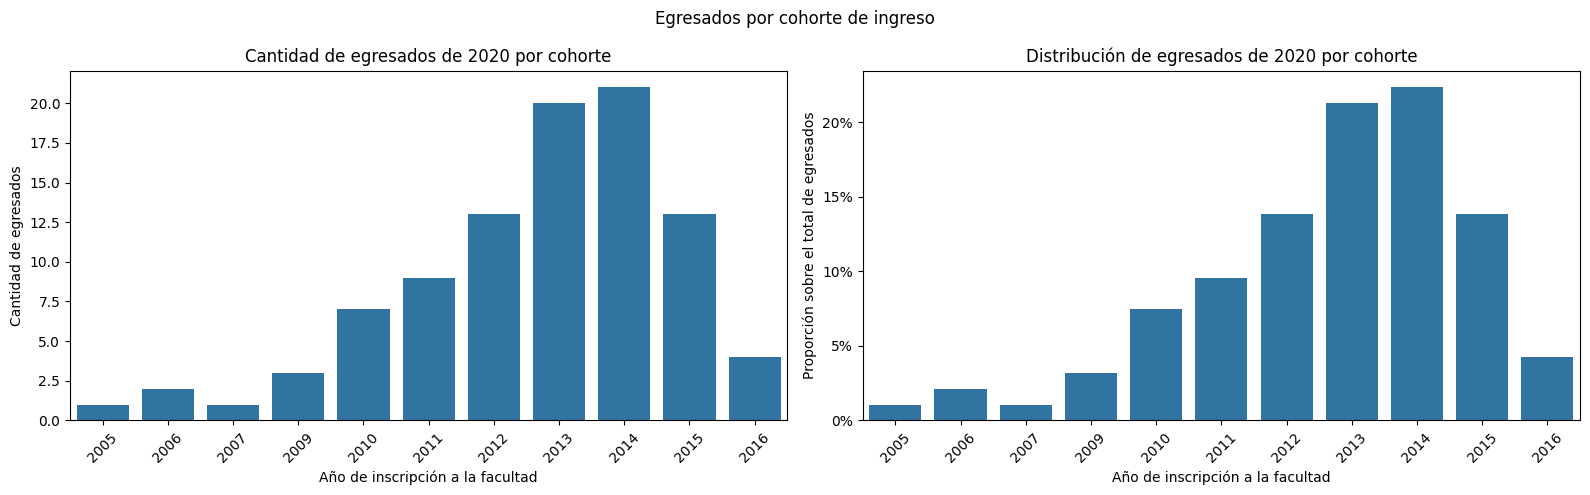

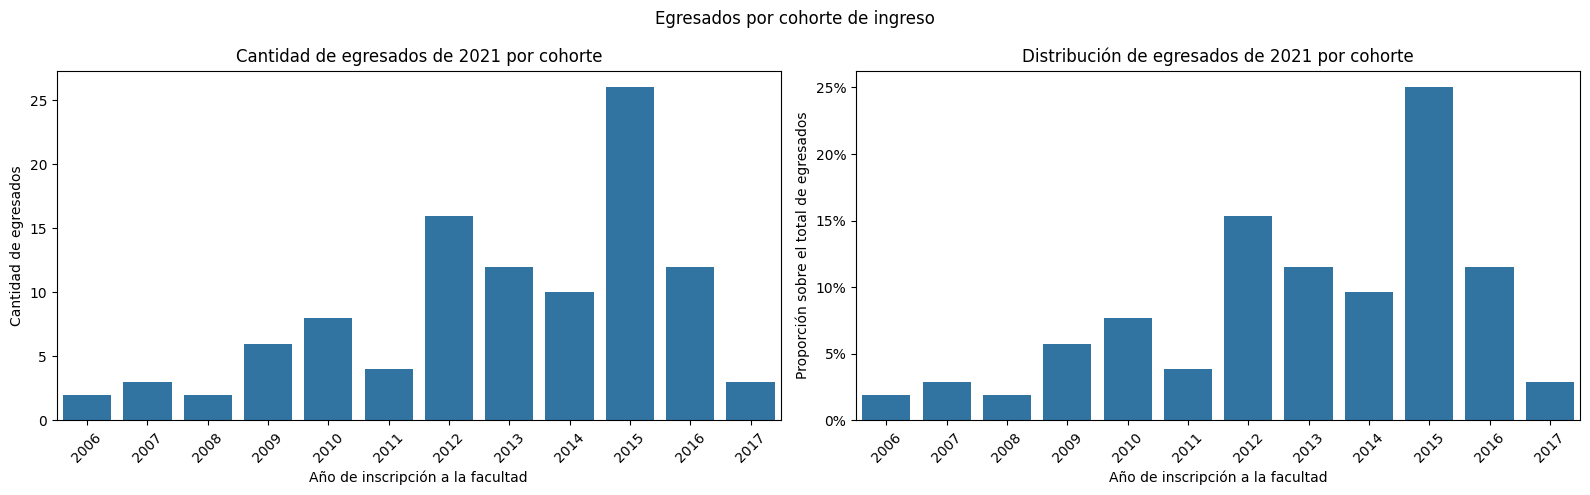

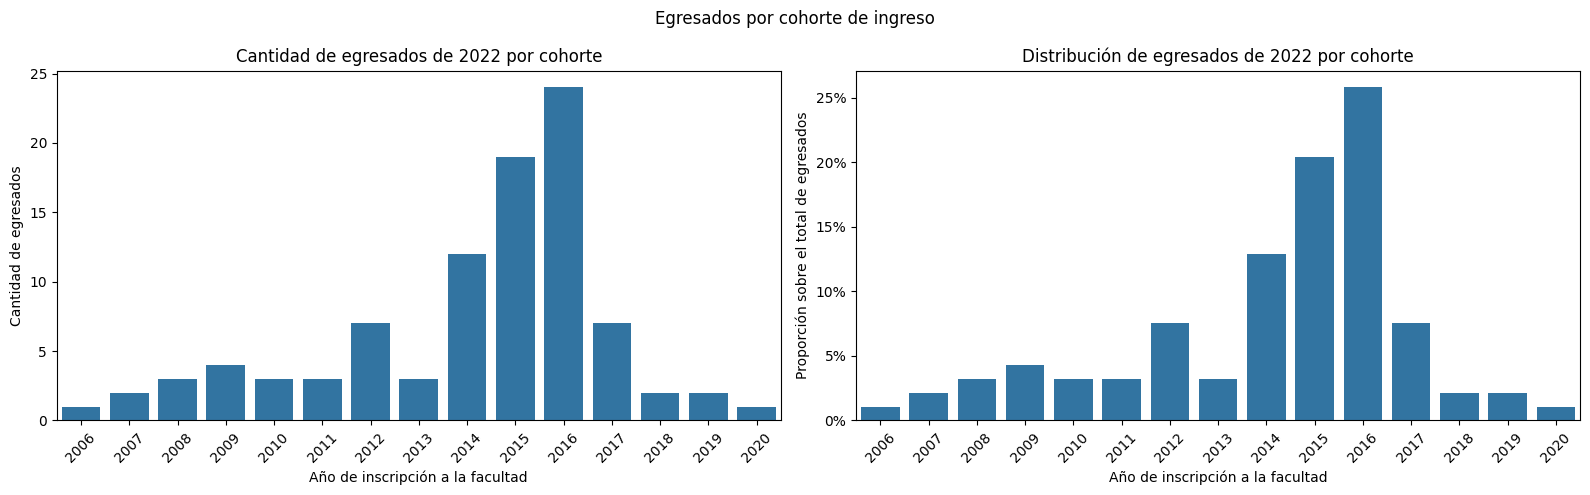

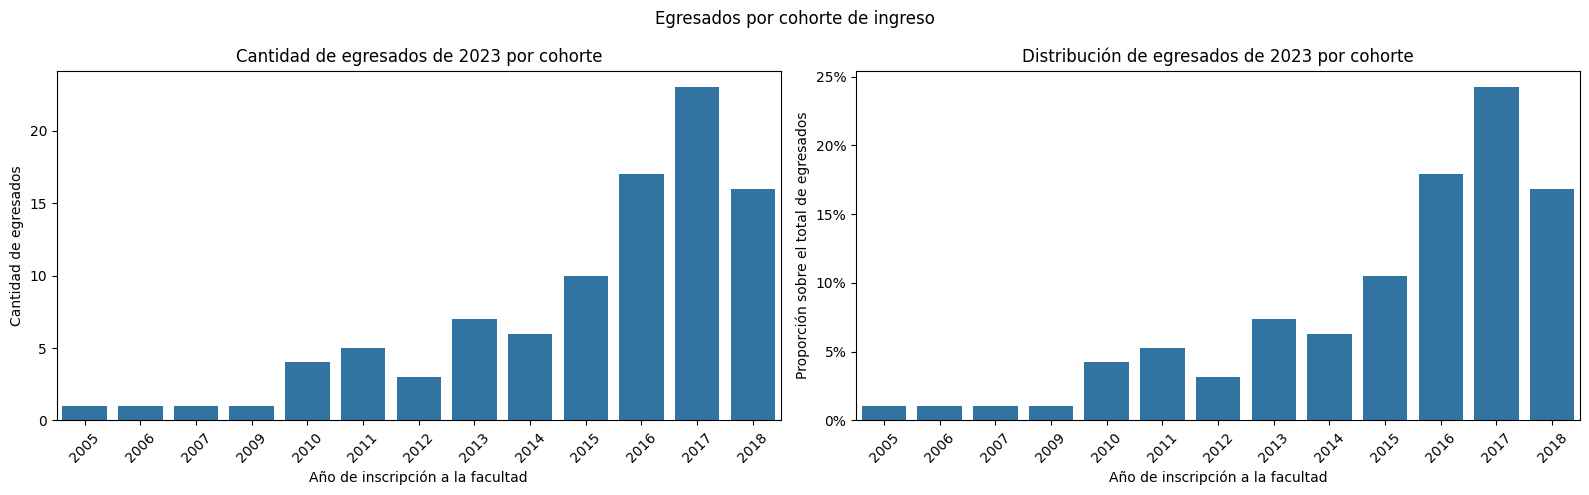

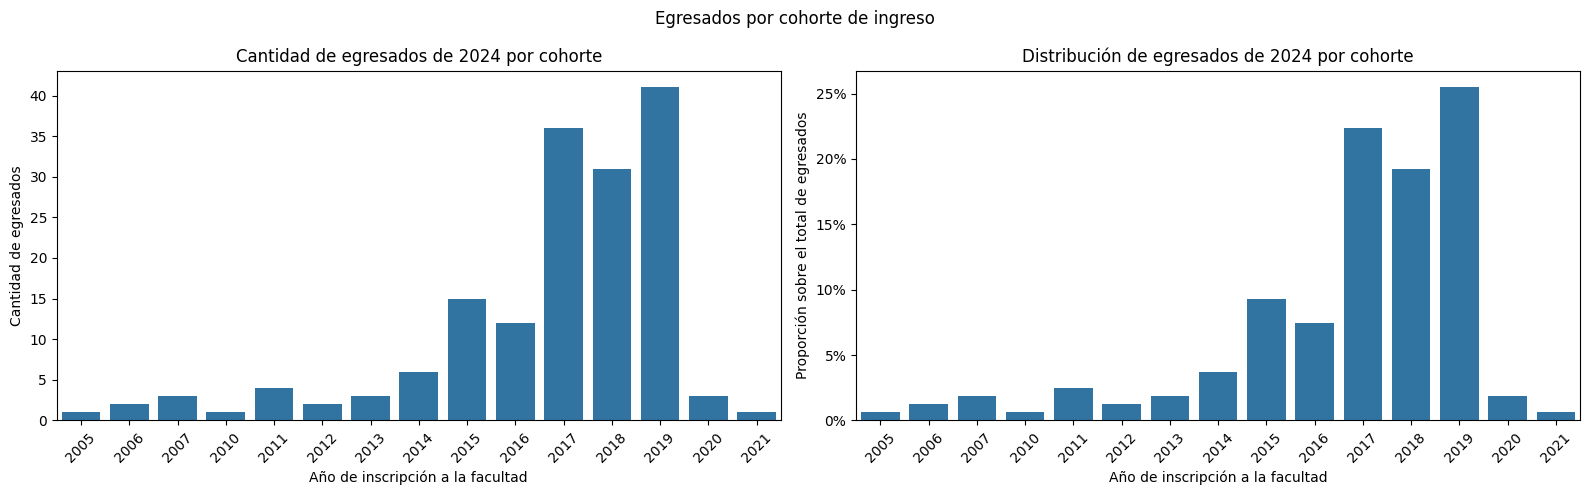

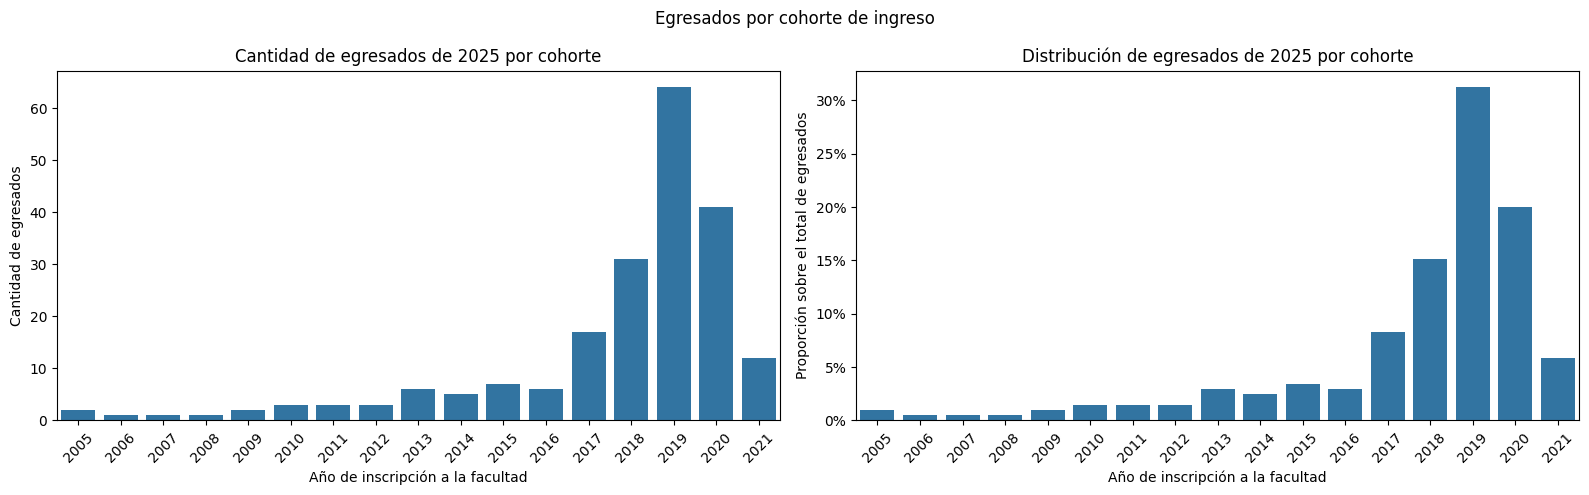

In [29]:
plot_egresados_biologia_por_anio(egresados_bio)

In [30]:
egresados_bio['tiempo_cursando'] = egresados_bio['anio_egreso'] - egresados_bio['año_inscripcion_facultad'] + 1

egresados_bio_filtrado = egresados_bio[(egresados_bio['anio_egreso'] >= 2014) & (egresados_bio['anio_egreso'] <= 2019)]

tabla_tiempo_cursando = (
    egresados_bio_filtrado.groupby('tiempo_cursando')['dni']
    .count()
    .reset_index()
    .rename(columns={'dni': 'total_egreso'})
    .sort_values('tiempo_cursando')
    .reset_index(drop=True)
)

tabla_tiempo_cursando

,tiempo_cursando,total_egreso
0,4,1
1,5,17
2,6,171
3,7,168
4,8,125
5,9,99
6,10,65
7,11,36
8,12,16
9,13,14


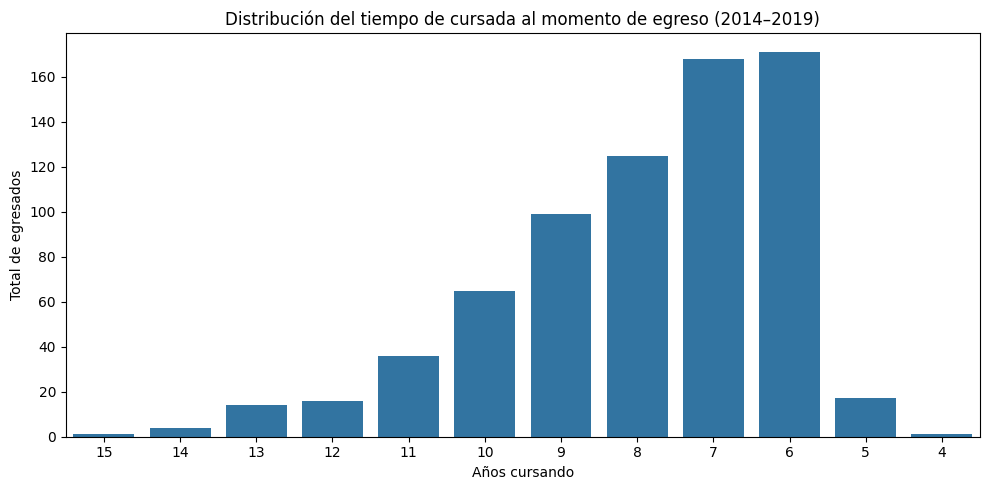

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

orden = tabla_tiempo_cursando.sort_values('tiempo_cursando', ascending=False)['tiempo_cursando'].tolist()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=tabla_tiempo_cursando, x='tiempo_cursando', y='total_egreso', order=orden, ax=ax)
ax.set_xlabel('Años cursando')
ax.set_ylabel('Total de egresados')
ax.set_title('Distribución del tiempo de cursada al momento de egreso (2014–2019)')
plt.tight_layout()
plt.show()

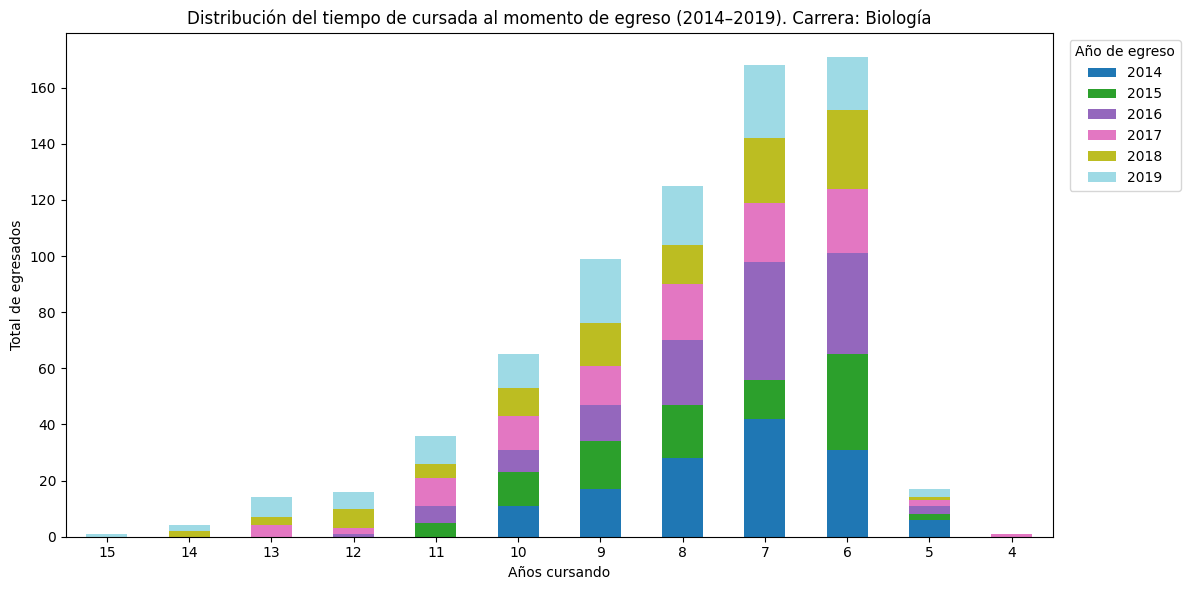

In [32]:
pivot = (
    egresados_bio_filtrado.groupby(['tiempo_cursando', 'anio_egreso'])['dni']
    .count()
    .unstack(fill_value=0)
)

# orden descendente en el eje x
pivot = pivot.loc[sorted(pivot.index, reverse=True)]

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_xlabel('Años cursando')
ax.set_ylabel('Total de egresados')
ax.set_title('Distribución del tiempo de cursada al momento de egreso (2014–2019). Carrera: Biología')
ax.legend(title='Año de egreso', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()